# Field SMF 00b · Stellar-mass completeness figure (Figure 12)

Publication figure for the field-sample completeness: (a) M* vs. M_r in one redshift slice with the 95th-percentile envelope and the completeness limit, (b) the per-slice completeness limits vs. redshift with the 2nd-order polynomial fit. Same sample selection as `00_FieldSMF_total.ipynb`.

**Input**: `DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv` (not included)

**Output**: `FIGURE/IMAGES/Figure12.pdf`

In [1]:
# ============================================================================
# Setup
# ============================================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from astropy.cosmology import LambdaCDM

# Cosmology used throughout this project
cosmo = LambdaCDM(H0=70, Om0=0.3, Ode0=0.7)

# Matplotlib style shared by the notebooks of this repository
plt.rcParams.update({
    "font.family": 'STIXGeneral',
    'text.usetex': False,
    "mathtext.fontset": 'cm',
    "axes.labelweight": "normal",
    'font.size': 25,
    'font.weight': 'normal',
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.top': True,
    'ytick.right': True,
    'xtick.minor.visible': True,
    'ytick.minor.visible': True,
    'xtick.major.size': 10,
    'xtick.minor.size': 6,
    'ytick.major.size': 10,
    'ytick.minor.size': 6,
    'xtick.major.width': 1.6,
    'xtick.minor.width': 1.6,
    'ytick.major.width': 1.6,
    'ytick.minor.width': 1.6,
    'lines.linewidth': 2,
    'axes.linewidth': 4,
    'axes.labelpad': 4,
    'xtick.major.pad': 7,
    'image.origin': 'lower'
})

# Show every column when a DataFrame is displayed
pd.set_option('display.max_columns', None)

# The nine MACH clusters
MACHLIST = ['A2245', 'A1767', 'A2244', 'A1831', 'A2034', 'A7', 'A2255', 'A2029', 'A2065']

# Repository root, located relative to this notebook; DATA/ and FIGURE/ hang off it
MAINPATH = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
FIGUREPATH = f"{MAINPATH}/FIGURE/IMAGES"

%config InlineBackend.figure_format = 'retina'

# 0. Import Main DataFrame

/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72959/360383663.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  spec_group = df0.groupby('mag_bin')
/Users/jonginpark/anaconda3/envs/work1/lib/python3.12/site-packages/astropy/cosmology/flrw/lambdacdm.py:397: RuntimeWarning: invalid value encountered in sqrt
  return 2 * np.sqrt(x) * hyp2f1(1.0 / 6, 1.0 / 2, 7.0 / 6, -(x**3))
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72959/360383663.py:24: RuntimeWarning: divide by zero encountered in log10
  df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(LambdaCDM(H0=70, Om0=0.3, Ode0=0.7).luminosity_distance(df0['z']).to('pc').value / 10)
/var/folders/8j/r5cxq2xj3bxdkw71t64p365m0000gn/T/ipykernel_72959/360383663.py:24: RuntimeWarning: invalid value encountered in log10
  df0['

Dn4000 completeness: 99.89%
Stellar mass completeness: 99.09%
Spectroscopic completeness of the field sample: 93.91%


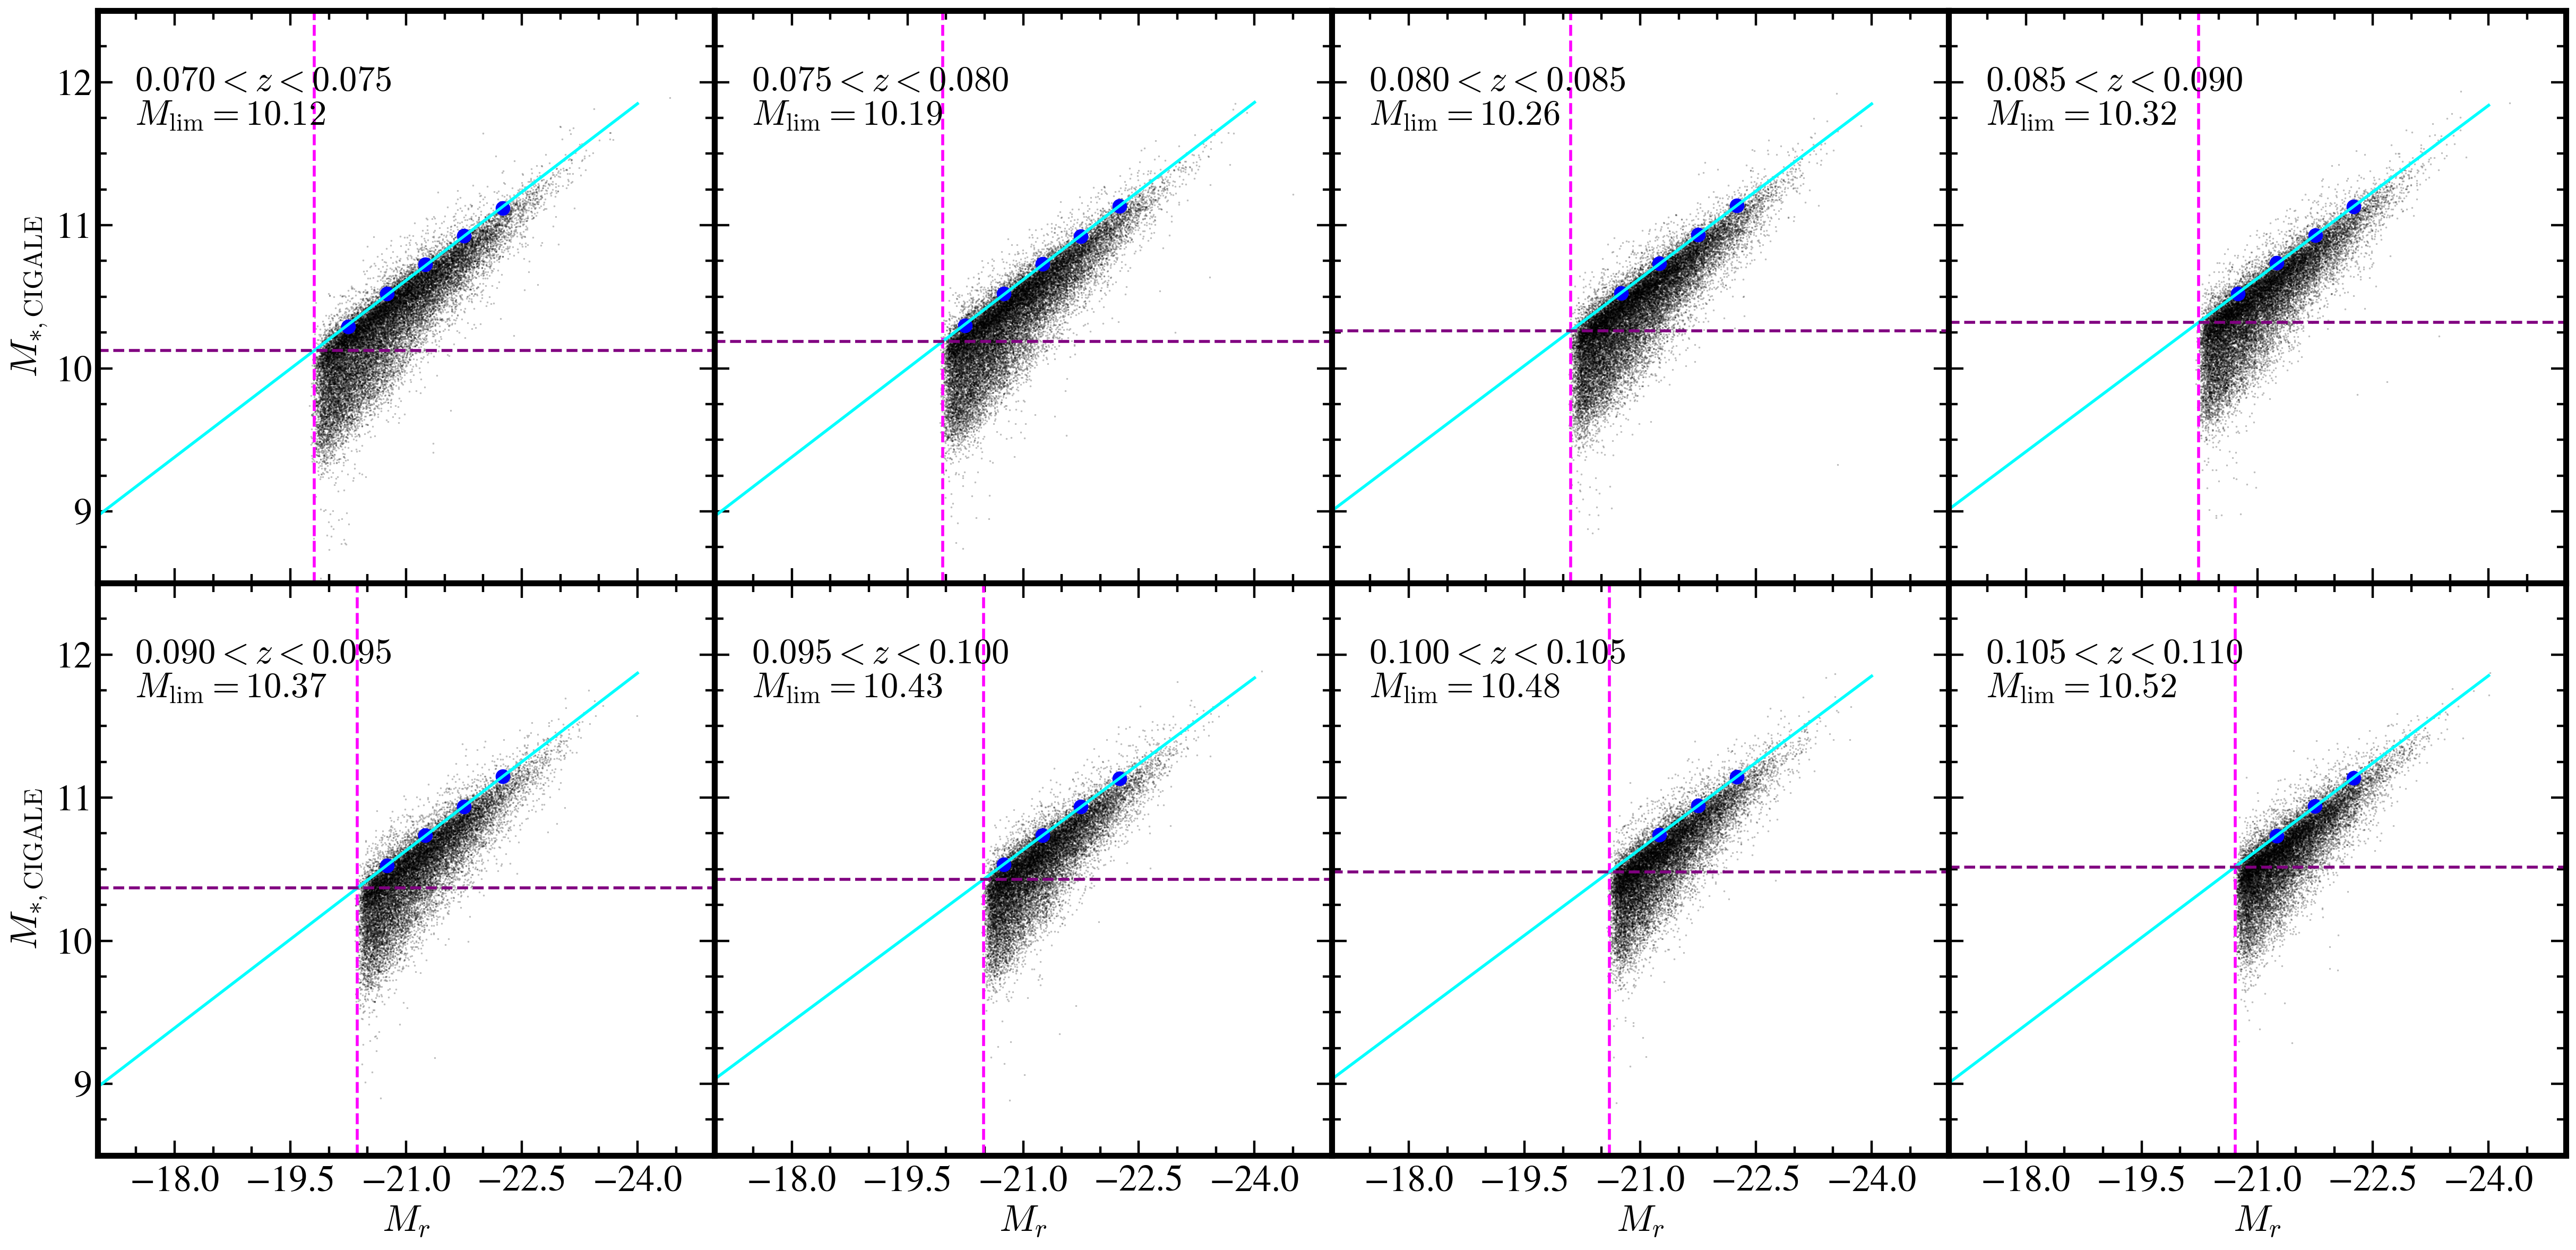

   z_center  axhline_value
0    0.0725      10.122800
1    0.0775      10.188511
2    0.0825      10.263260
3    0.0875      10.319559
4    0.0925      10.367594
5    0.0975      10.429031
6    0.1025      10.481526
7    0.1075      10.515698


In [2]:
from sklearn.linear_model import LinearRegression

# Load catalog
df0 = pd.read_csv(f'{MAINPATH}/DATA/FIELD/SDSS_MGS/SDSS_DR18_mgs_mastercat.csv')

# --- Spectroscopic incompleteness correction by r-band apparent magnitude ---
rmag_bins = np.arange(5, 20.25, 0.25)
rmag_centers = rmag_bins[:-1] + 0.05
df0['mag_bin'] = pd.cut(df0['petroMag_r'], bins=rmag_bins, labels=rmag_centers, include_lowest=True)

spec_group = df0.groupby('mag_bin')
total_per_bin = spec_group.size()
validz_per_bin = spec_group['z'].apply(lambda z: (z != -99).sum())
spec_completeness = (validz_per_bin / total_per_bin).replace(0, np.nan)
df0['w_spec'] = df0['mag_bin'].map(lambda mb: 1 / spec_completeness.get(mb, np.nan))
df0.drop(columns='mag_bin', inplace=True)

# --- Add absolute r-band magnitude (corrected for extinction) ---
df0['petroMag_r_0'] = df0['petroMag_r'] - df0['extinction_r']
df0['AbsMag_r'] = df0['petroMag_r_0'] - 5 * np.log10(cosmo.luminosity_distance(df0['z']).to('pc').value / 10)

# --- Field sample selection: 0.07 < z < 0.11 ---
df = df0[(df0['z'] > 0.07) & (df0['z'] < 0.11)].copy()

# --- Completeness fractions ---
dn4000_comp = (df['Dn4000'] != -99).mean()
mass_comp = (df['M_MASS_CIGALE'] != -99).mean()
main_mask = df0['petroMag_r'] < 17.77
spec_comp_field = (df0.loc[main_mask, 'z'] != -99).sum() / main_mask.sum()

print(f"Dn4000 completeness: {dn4000_comp * 100:.2f}%")
print(f"Stellar mass completeness: {mass_comp * 100:.2f}%")
print(f"Spectroscopic completeness of the field sample: {spec_comp_field * 100:.2f}%")

# Restrict to objects with reliable stellar mass
df = df[df['M_MASS_CIGALE'] != -99].copy()

# --- Sliding mass completeness: plot in 8 adjacent redshift bins ---
z_bin_edges = np.arange(0.07, 0.11 + 0.005/2, 0.005)
z_bin_ranges = [(z_bin_edges[i], z_bin_edges[i+1]) for i in range(len(z_bin_edges)-1)]
df_compline = pd.DataFrame(columns=['z_center', 'axhline_value'])

fig, axes = plt.subplots(2, 4, figsize=(30, 14), sharex=True, sharey=True)
axes = axes.flatten()

for i, (zmin, zmax) in enumerate(z_bin_ranges):
    ax = axes[i]
    bin_mask = (df['z'] >= zmin) & (df['z'] < zmax)
    subdf = df[bin_mask]

    z_mid = 0.5 * (zmin + zmax)
    d_lum = cosmo.luminosity_distance(z_mid).value  # Mpc
    m_sdss = 17.77
    M_r_lim = m_sdss - 5 * (np.log10(d_lum * 1e6) - 1)

    filtered = subdf[(subdf['AbsMag_r'] < M_r_lim) & (subdf['AbsMag_r'] > -22.5)]
    if not filtered.empty:
        bin_edges = np.arange(filtered['AbsMag_r'].min(), filtered['AbsMag_r'].max(), 0.5)
        bin_labels = pd.cut(filtered['AbsMag_r'], bins=bin_edges, include_lowest=True)
        binned = filtered.groupby(bin_labels)

        bin_centers = []
        top10_mass = []
        for rng, g in binned:
            if not g.empty:
                bin_centers.append(rng.mid)
                top10_mass.append(g['M_MASS_CIGALE'].quantile(0.9))
        bin_centers = np.array(bin_centers)
        top10_mass = np.array(top10_mass)

        # Fit linear
        if len(bin_centers) > 1:
            reg = LinearRegression().fit(bin_centers.reshape(-1,1), top10_mass)
            x_range = np.linspace(-24, -15, 100)
            y_pred = reg.predict(x_range.reshape(-1,1))
            y_inter = reg.predict([[M_r_lim]])[0]
        else:
            x_range = np.array([])
            y_pred = np.array([])
            y_inter = np.nan
    else:
        bin_centers = np.array([])
        top10_mass = np.array([])
        x_range = np.array([])
        y_pred = np.array([])
        y_inter = np.nan

    df_compline = pd.concat([
        df_compline,
        pd.DataFrame({'z_center':[z_mid], 'axhline_value':[y_inter]})
    ], ignore_index=True)

    ax.scatter(subdf['AbsMag_r'], subdf['M_MASS_CIGALE'], color='black', s=0.01)
    ax.axvline(M_r_lim, color='magenta', linestyle='--')
    if len(bin_centers):
        ax.scatter(bin_centers, top10_mass, color='blue', s=80)
    if len(x_range):
        ax.plot(x_range, y_pred, color='cyan')
    if not np.isnan(y_inter):
        ax.axhline(y_inter, color='purple', linestyle='--')

    ax.tick_params(axis='x', which='both', direction='in', top=True, labelbottom=(i//4==1))
    ax.tick_params(axis='y', which='both', direction='in', right=True, labelleft=(i%4==0))
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
    ax.xaxis.set_major_locator(plt.MultipleLocator(1.5))
    ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))

    if i % 4 == 0:
        ax.set_ylabel(r'$M_{\ast,\rm CIGALE}$')
    if i // 4 == 1:
        ax.set_xlabel(r'$M_r$')

    ax.set_xlim(-25, -17)
    ax.invert_xaxis()
    ax.set_ylim(8.5, 12.5)

    ax.text(0.06, 0.86, f'${zmin:.3f}<z<{zmax:.3f}$', transform=ax.transAxes, fontsize=24)
    if not np.isnan(y_inter):
        ax.text(0.06, 0.80, rf'$M_{{\rm lim}}={y_inter:.2f}$', transform=ax.transAxes, fontsize=24)

for ax in axes[len(z_bin_ranges):]:
    ax.axis('off')

plt.subplots_adjust(wspace=0, hspace=0)

plt.show()

print(df_compline)

# 1. Main Plot

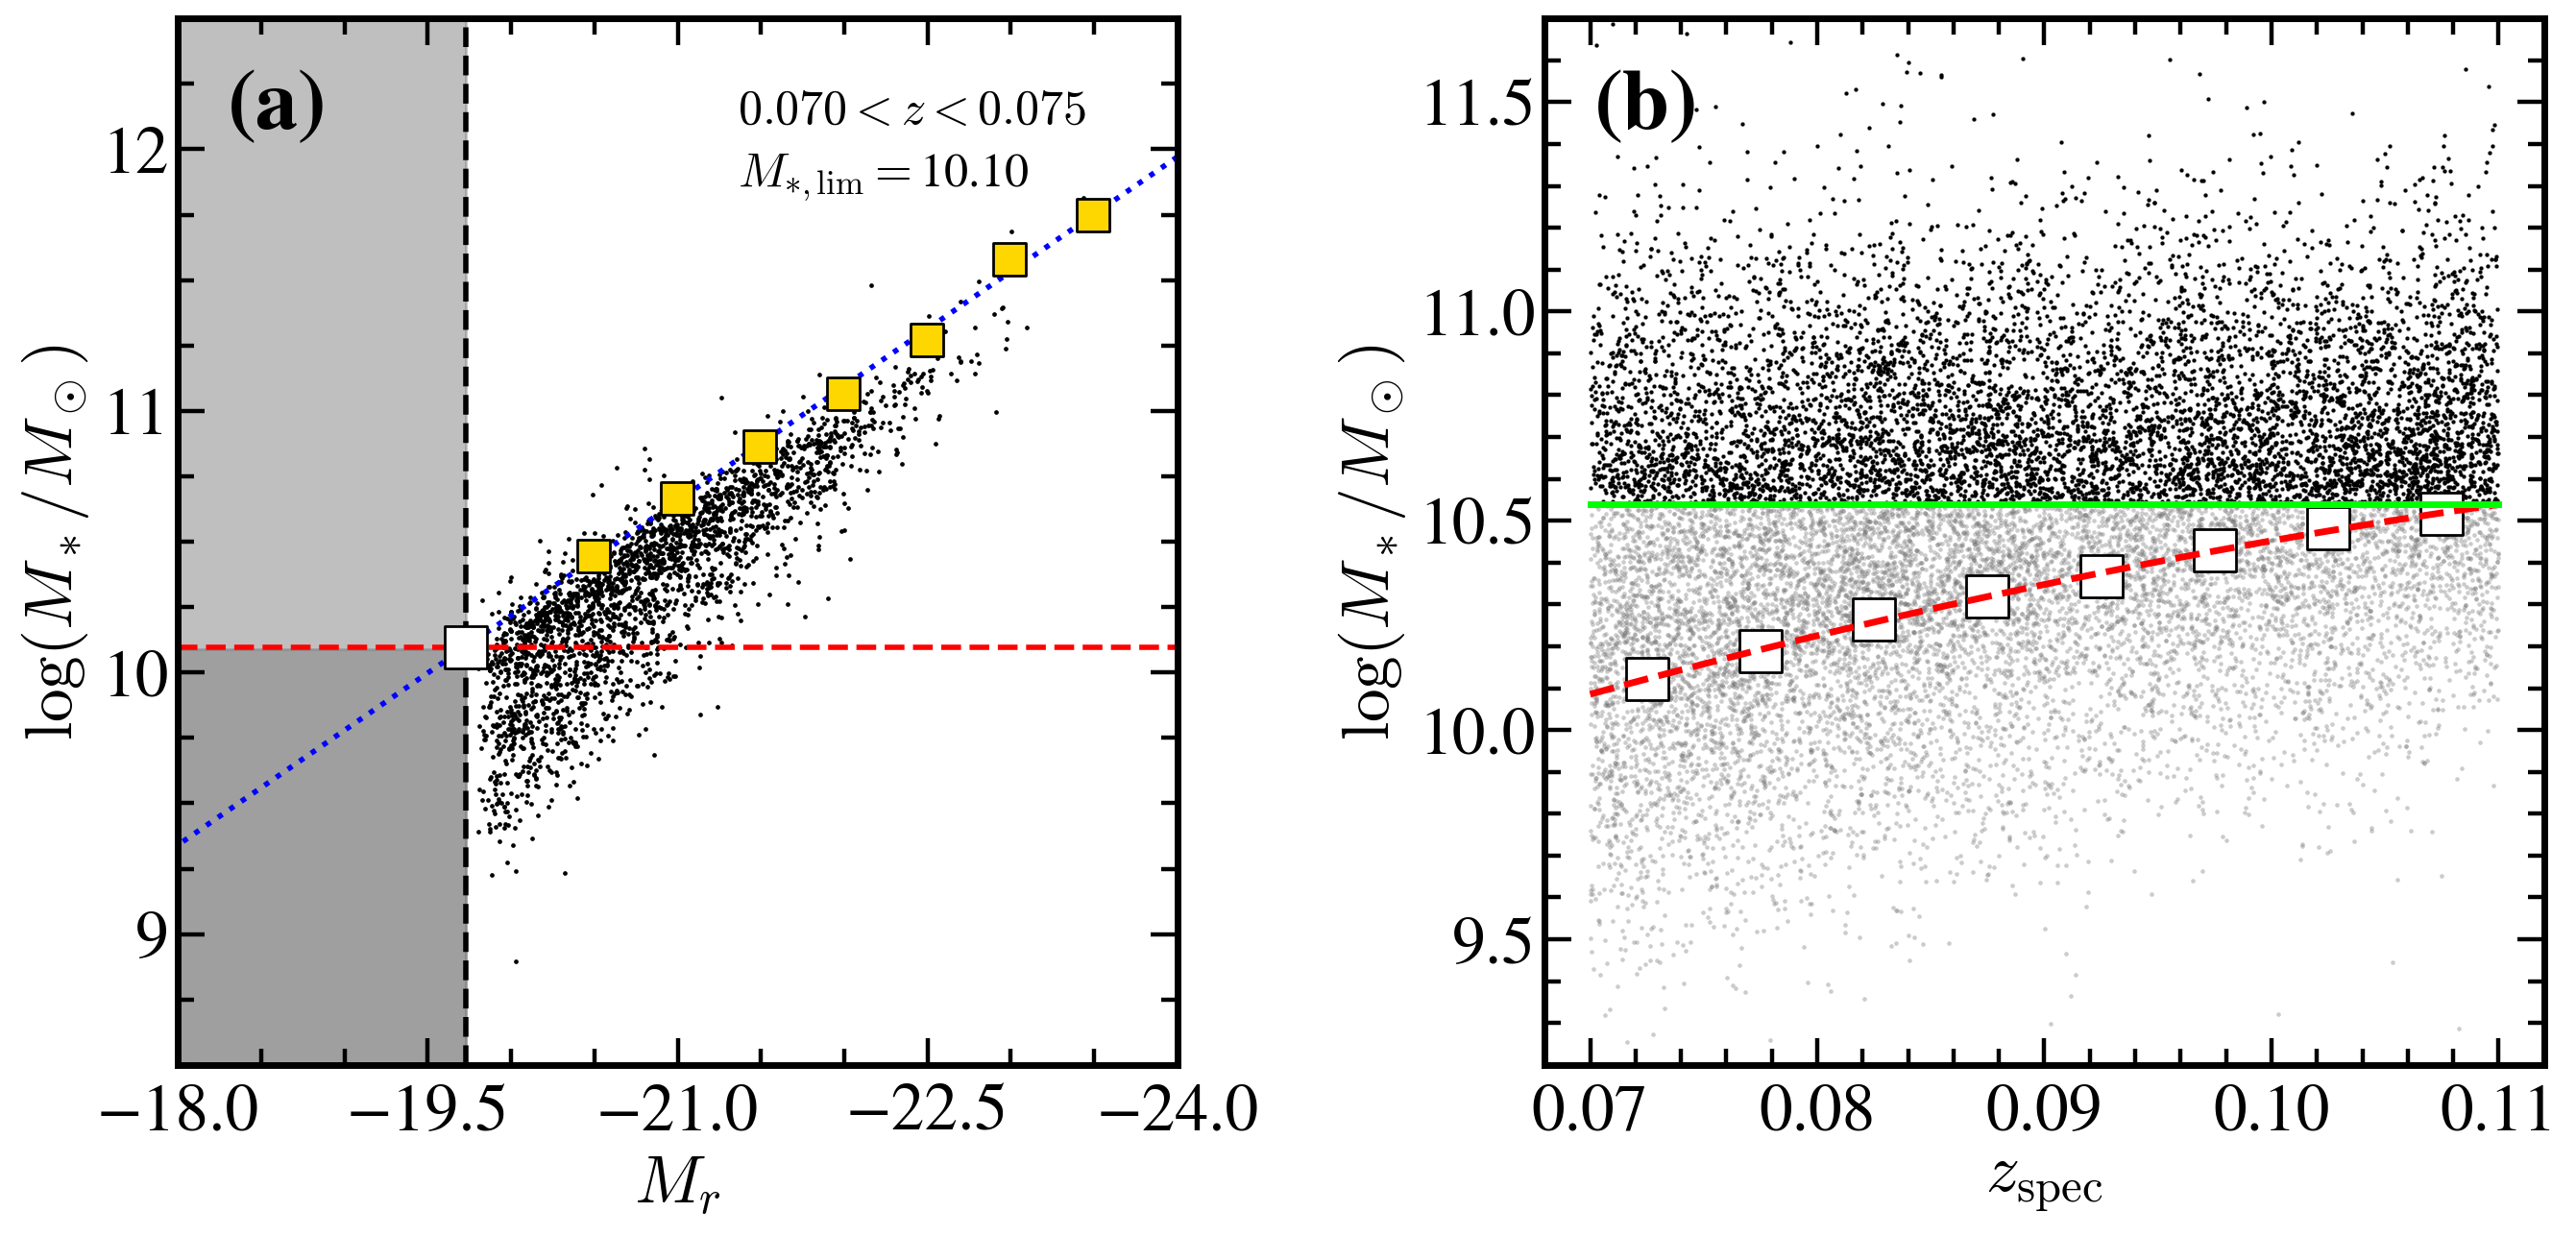

M_lim at z=0.11 (survey boundary) : 10.54
M_lim at z=0.07 (survey start)    : 10.09
Polynomial coefficients [a0,a1,a2] : ['8.608', '27.326', '-88.836']
Polynomial domain                  : [0.0725 0.1075]


In [4]:
from sklearn.linear_model import LinearRegression
from numpy.polynomial.polynomial import Polynomial

# ============================================================
# Two-panel figure:
#   (a) Mass completeness in one redshift slice (M_r vs M_*)
#   (b) Completeness polynomial vs redshift (z vs M_*)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=False)

# ──────────────────────────────────────────────
# PANEL (a): Redshift-slice completeness diagram
# ──────────────────────────────────────────────

ax = axes[0]

# Use the first Δz = 0.005 slice to illustrate completeness
z_lo, z_hi = 0.07, 0.075
z_cen = 0.5 * (z_lo + z_hi)

in_slice = (df["z"] >= z_lo) & (df["z"] < z_hi)
sub = df[in_slice]

# Apparent-magnitude limit → absolute-magnitude limit at z_lo
d_L   = cosmo.luminosity_distance(z_lo).value     # [Mpc]
M_lim = 17.77 - 5.0 * (np.log10(d_L * 1e6) - 1.0)

# Restrict to [M_lim, -24] to exclude BCG-bright objects
sub_filt = sub[(sub["AbsMag_r"] < M_lim) & (sub["AbsMag_r"] > -24.0)]

# 95th-percentile M_* in 0.5-mag bins of M_r
mag_bins = np.arange(sub_filt["AbsMag_r"].min(), sub_filt["AbsMag_r"].max(), 0.5)
groups   = sub_filt.groupby(pd.cut(sub_filt["AbsMag_r"], mag_bins, include_lowest=True))

bin_mids, p95_mass = [], []
for interval, grp in groups:
    if len(grp) == 0:
        continue
    bin_mids.append(interval.mid)
    p95_mass.append(grp["M_MASS_CIGALE"].quantile(0.95))

bin_mids  = np.array(bin_mids)
p95_mass  = np.array(p95_mass)

# Linear fit to the 95th-percentile ridge
reg   = LinearRegression().fit(bin_mids.reshape(-1, 1), p95_mass)
x_fit = np.linspace(-24.0, -15.0, 100)
y_fit = reg.predict(x_fit.reshape(-1, 1))

# Stellar-mass completeness limit at the apparent-magnitude boundary
M_star_lim = reg.predict([[M_lim]])[0]

# ── Scatter: subsample 10 % to avoid over-plotting ──────────
sampled = sub.sample(frac=0.1, random_state=42)
ax.scatter(sampled["AbsMag_r"], sampled["M_MASS_CIGALE"],
           color="black", s=0.5)

# Completeness boundaries
ax.axvline(M_lim, color="black", linestyle="--", linewidth=2)
ax.axhline(M_star_lim, color="red",   linestyle="--", linewidth=2)

# 95th-percentile points and fit line
ax.scatter(bin_mids, p95_mass,
           color="gold", s=150, marker="s", edgecolors="black", zorder=4)
ax.plot(x_fit, y_fit, color="blue", linestyle=":", linewidth=2)

# White square at the intersection (M_lim, M_star_lim)
ax.scatter([M_lim], [M_star_lim], s=250, marker="s",
           facecolor="white", edgecolor="black", zorder=5)

# Gray regions: below M_star_lim (vertically) and faint of M_lim (horizontally)
ax.fill_betweenx(np.arange(8.5, M_star_lim, 0.01),
                 M_lim, ax.get_xlim()[1] if ax.get_xlim()[1] else -18.0,
                 color="gray", alpha=0.5, zorder=0)
ax.fill_between(np.arange(M_lim, -15.0, 0.01),
                6.5, 13.0, color="gray", alpha=0.5)

# Axes formatting
ax.set_xlabel(r"$M_r$",                              fontsize=25)
ax.set_ylabel(r"$\log(M_\ast/M_\odot)$",             fontsize=25)
ax.set_xlim(-24.0, -18.0)
ax.set_ylim(8.5, 12.5)
ax.invert_xaxis()
ax.tick_params(axis="x", which="both", direction="in", top=True)
ax.tick_params(axis="y", which="both", direction="in", right=True)
ax.minorticks_on()
ax.xaxis.set_minor_locator(plt.MultipleLocator(0.5))
ax.xaxis.set_major_locator(plt.MultipleLocator(1.5))
ax.yaxis.set_minor_locator(plt.MultipleLocator(0.25))
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.text(0.56, 0.90, f"${z_lo:.3f} < z < {z_hi:.3f}$",
        fontsize=18, transform=ax.transAxes)
ax.text(0.56, 0.84, r"$M_{\ast,\rm lim} = $" + f"{M_star_lim:.2f}",
        fontsize=18, transform=ax.transAxes)
ax.text(0.05, 0.95, "(a)", transform=ax.transAxes,
        fontsize=32, fontweight="bold", va="top", ha="left")

# ──────────────────────────────────────────────
# PANEL (b): Completeness polynomial p(z) vs M_*
# ──────────────────────────────────────────────

ax = axes[1]

# Fit a 2nd-order polynomial to the per-slice completeness limits
# (df_compline must have columns 'z_center' and 'axhline_value')
p = Polynomial.fit(df_compline["z_center"], df_compline["axhline_value"], deg=2)
z_grid = np.linspace(0.07, 0.11, 100)
M_grid = p(z_grid)

# Horizontal threshold: completeness limit at the survey boundary z = 0.11
M_lim_survey = float(p(0.11))

# Subsample 10 % of galaxies for the scatter layer
z_samp   = df["z"].sample(frac=0.1, random_state=42)
M_samp   = df["M_MASS_CIGALE"].sample(frac=0.1, random_state=42)

# Gray out galaxies below the polynomial curve OR below the survey threshold
below = (M_samp < p(z_samp)) | (M_samp < M_lim_survey)

ax.scatter(z_samp[below],  M_samp[below],
           color="gray", s=2.2, alpha=0.4,
           edgecolor="black", linewidth=0.05, zorder=1)
ax.scatter(z_samp[~below], M_samp[~below],
           color="black", s=2.2, alpha=1.0,
           edgecolor="black", linewidth=0.05, zorder=2)

# White squares at the per-slice completeness nodes
ax.scatter(df_compline["z_center"], df_compline["axhline_value"],
           color="white", edgecolor="black", s=250, marker="s", zorder=4)

# Polynomial curve (red dashed) and horizontal threshold (lime)
ax.plot(z_grid, M_grid,                         color="red",  linestyle="--", lw=2.5, zorder=5)
ax.plot(z_grid, np.full_like(z_grid, M_lim_survey), color="lime", linestyle="-",  lw=2.5, zorder=5)

# Axes formatting
ax.set_xlabel(r"$z_{\rm spec}$",            fontsize=25)
ax.set_ylabel(r"$\log(M_*/M_\odot)$",       fontsize=25)
ax.set_xticks([0.07, 0.08, 0.09, 0.10, 0.11])
ax.set_ylim(9.2, 11.7)
ax.tick_params(axis="x", which="both", direction="in", top=True)
ax.tick_params(axis="y", which="both", direction="in", right=True)
ax.minorticks_on()
for spine in ax.spines.values():
    spine.set_linewidth(2.5)

ax.text(0.05, 0.95, "(b)", transform=ax.transAxes,
        fontsize=32, fontweight="bold", va="top", ha="left")

plt.tight_layout()
plt.savefig(f"{MAINPATH}/FIGURE/IMAGES/Figure12.pdf", format="pdf", dpi=150, bbox_inches="tight")
plt.show()

# ──────────────────────────────────────────────
# Summary: key completeness values
# ──────────────────────────────────────────────
print(f"M_lim at z=0.11 (survey boundary) : {M_lim_survey:.2f}")
print(f"M_lim at z=0.07 (survey start)    : {float(p(0.07)):.2f}")
print(f"Polynomial coefficients [a0,a1,a2] : {[f'{c:.3f}' for c in p.convert().coef]}")
print(f"Polynomial domain                  : {p.domain}")